In [1]:
# ─────────────────────────────────────────────────────────────
# CELL 1 — Imports and Connections
# ─────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import requests
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

In [2]:
# ─────────────────────────────────────────────────────────────
# CELL 2 — Load Local Inverter Data from CSV
# ─────────────────────────────────────────────────────────────

# Update path to where your CSV is saved on your laptop
csv_path = "D:\Desktop\ESSCO\essco-ai\Dataset\TKKHEAD01\semply_cloud.meter.solar.1.csv" 

df_inverter = pd.read_csv(csv_path)

# 1. Standardize column mapping (Ensuring 'timestamp' and 'ac_power_total')
# If your CSV uses a different timestamp column name (like 'time' or 'date'), update it on the right side below:
df_inverter = df_inverter.rename(columns={
    "dateTime": "timestamp",   # Replace "time" if your column name is different
    "pTot": "ac_power_total"
})

# 2. Keep only required columns and remove missing records
keep_cols = ["timestamp", "ac_power_total"]
df_inverter = df_inverter[keep_cols].dropna(subset=["ac_power_total"])

print(f"✅ Inverter CSV data loaded → shape: {df_inverter.shape}")
print(f"   Date range: {df_inverter['timestamp'].min()}  →  {df_inverter['timestamp'].max()}\n")
df_inverter.head(3)

✅ Inverter CSV data loaded → shape: (316922, 2)
   Date range: 2025-11-08T03:46:23.000Z  →  2026-06-19T12:54:01.000Z



,timestamp,ac_power_total
0,2026-06-19T12:54:01.000Z,23.20
1,2026-06-19T12:53:01.000Z,17.22
2,2026-06-19T12:52:01.000Z,22.10


Points for 2026-06-18: 1249
First: 2026-06-18 00:00:56  |  Last: 2026-06-18 23:59:14


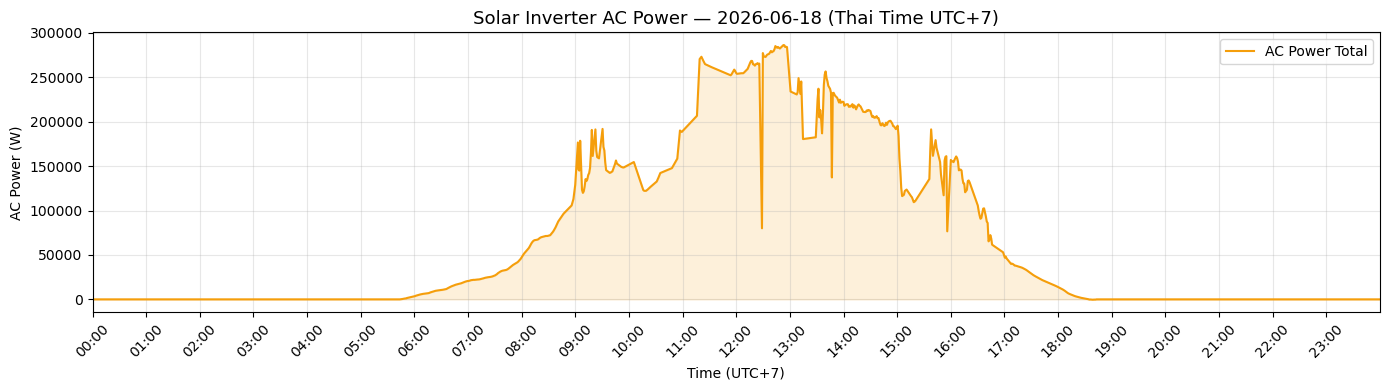

In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 3 — Plot Single Full Day (Thai Time)
# ─────────────────────────────────────────────────────────────

# ✅ Parse and convert to Thai time (if not already done)
df_inverter["timestamp"] = (
    pd.to_datetime(df_inverter["timestamp"], utc=True)
      .dt.tz_convert("Asia/Bangkok")
)

TARGET_DATE = "2026-06-18"  # ← change this to any date

# Filter by Thai date
mask = df_inverter["timestamp"].dt.date == pd.Timestamp(TARGET_DATE).date()
df_day = df_inverter[mask].sort_values("timestamp")

# Strip tz for matplotlib
times = df_day["timestamp"].dt.tz_localize(None)

print(f"Points for {TARGET_DATE}: {len(df_day)}")
print(f"First: {times.iloc[0]}  |  Last: {times.iloc[-1]}")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(times, df_day["ac_power_total"],
        color="#f59e0b", linewidth=1.5, label="AC Power Total")
ax.fill_between(times, df_day["ac_power_total"],
                alpha=0.15, color="#f59e0b")

ax.set_xlim(pd.Timestamp(TARGET_DATE + " 00:00:00"),
            pd.Timestamp(TARGET_DATE + " 23:59:59"))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xticks(rotation=45)
plt.margins(x=0)

ax.set_title(f"Solar Inverter AC Power — {TARGET_DATE} (Thai Time UTC+7)", fontsize=13)
ax.set_xlabel("Time (UTC+7)")
ax.set_ylabel("AC Power (W)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()